In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [5]:
df=pd.read_csv("Funnel_Data_Analysis.csv")
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2026-05-05 15:19:35,Desktop,West,Organic,Electronics,0.0,Yes
1,USR00002,SES00002,Browse,2026-05-14 09:14:58,Phone,South,Organic,Fashion,0.0,Yes
2,USR00002,SES00002,Add To Cart,2026-05-14 09:18:58,Tablet,East,Google Ads,Home,0.0,Yes
3,USR00003,SES00003,Browse,2026-05-08 16:03:09,Phone,North,Organic,Electronics,0.0,Yes
4,USR00004,SES00004,Browse,2026-05-09 19:40:20,Phone,South,Organic,Fashion,0.0,Yes


In [6]:
df.shape

(53745, 10)

In [7]:
df.columns

Index(['User_ID', 'Session_ID', 'Event', 'Timestamp', 'Device', 'Region',
       'Channel', 'Product_Category', 'Revenue', 'Bounce_Flag'],
      dtype='str')

In [8]:
df.dtypes

User_ID                 str
Session_ID              str
Event                   str
Timestamp               str
Device                  str
Region                  str
Channel                 str
Product_Category        str
Revenue             float64
Bounce_Flag             str
dtype: object

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53745 entries, 0 to 53744
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           53745 non-null  str    
 1   Session_ID        53745 non-null  str    
 2   Event             53745 non-null  str    
 3   Timestamp         53745 non-null  str    
 4   Device            53745 non-null  str    
 5   Region            53745 non-null  str    
 6   Channel           53745 non-null  str    
 7   Product_Category  53745 non-null  str    
 8   Revenue           53745 non-null  float64
 9   Bounce_Flag       53745 non-null  str    
dtypes: float64(1), str(9)
memory usage: 7.8 MB


In [10]:
df.size

537450

In [11]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
print(df.dtypes)

User_ID                        str
Session_ID                     str
Event                          str
Timestamp           datetime64[us]
Device                         str
Region                         str
Channel                        str
Product_Category               str
Revenue                    float64
Bounce_Flag                    str
dtype: object


In [12]:
df.describe()

,Timestamp,Revenue
count,53745,53745.000000
mean,2026-05-07 00:31:41.737147,52.341069
min,2026-04-22 02:58:39,0.000000
25%,2026-04-29 11:52:39,0.000000
50%,2026-05-06 23:51:20,0.000000
75%,2026-05-14 11:06:13,0.000000
max,2026-05-22 02:59:14,1999.090000
std,NaN,260.320511


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53745 entries, 0 to 53744
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           53745 non-null  str           
 1   Session_ID        53745 non-null  str           
 2   Event             53745 non-null  str           
 3   Timestamp         53745 non-null  datetime64[us]
 4   Device            53745 non-null  str           
 5   Region            53745 non-null  str           
 6   Channel           53745 non-null  str           
 7   Product_Category  53745 non-null  str           
 8   Revenue           53745 non-null  float64       
 9   Bounce_Flag       53745 non-null  str           
dtypes: datetime64[us](1), float64(1), str(8)
memory usage: 6.8 MB


In [14]:
df.describe(include="object")

C:\Users\USER\AppData\Local\Temp\ipykernel_14488\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,User_ID,Session_ID,Event,Device,Region,Channel,Product_Category,Bounce_Flag
count,53745,53745,53745,53745,53745,53745,53745,53745
unique,25000,25000,4,3,4,4,5,2
top,USR00016,SES00016,Browse,Desktop,West,Google Ads,Fashion,Yes
freq,4,4,25000,18039,13587,13463,10895,43489


In [15]:
df.shape

(53745, 10)

In [16]:
pd.set_option("display.max_rows",None)

In [17]:
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2026-05-05 15:19:35,Desktop,West,Organic,Electronics,0.0,Yes
1,USR00002,SES00002,Browse,2026-05-14 09:14:58,Phone,South,Organic,Fashion,0.0,Yes
2,USR00002,SES00002,Add To Cart,2026-05-14 09:18:58,Tablet,East,Google Ads,Home,0.0,Yes
3,USR00003,SES00003,Browse,2026-05-08 16:03:09,Phone,North,Organic,Electronics,0.0,Yes
4,USR00004,SES00004,Browse,2026-05-09 19:40:20,Phone,South,Organic,Fashion,0.0,Yes


**Explatory Data Analysis**

In [18]:
df.isnull().sum()

User_ID             0
Session_ID          0
Event               0
Timestamp           0
Device              0
Region              0
Channel             0
Product_Category    0
Revenue             0
Bounce_Flag         0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.nunique()

User_ID             25000
Session_ID          25000
Event                   4
Timestamp           53215
Device                  3
Region                  4
Channel                 4
Product_Category        5
Revenue              2548
Bounce_Flag             2
dtype: int64

In [21]:
df["Event_sequence"]=df.groupby("Session_ID").cumcount()+1

In [22]:
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Event_sequence
0,USR00001,SES00001,Browse,2026-05-05 15:19:35,Desktop,West,Organic,Electronics,0.0,Yes,1
1,USR00002,SES00002,Browse,2026-05-14 09:14:58,Phone,South,Organic,Fashion,0.0,Yes,1
2,USR00002,SES00002,Add To Cart,2026-05-14 09:18:58,Tablet,East,Google Ads,Home,0.0,Yes,2
3,USR00003,SES00003,Browse,2026-05-08 16:03:09,Phone,North,Organic,Electronics,0.0,Yes,1
4,USR00004,SES00004,Browse,2026-05-09 19:40:20,Phone,South,Organic,Fashion,0.0,Yes,1


In [23]:
df["Date"]=df["Timestamp"].dt.date
df["Day_Of_Week"]=df["Timestamp"].dt.day_name()
df["Hour"]=df["Timestamp"].dt.hour
df["Week_Number"]=df["Timestamp"].dt.isocalendar().week

In [24]:
print(f'\n range {df["Date"].min()} to {df["Date"].max()}')


 range 2026-04-22 to 2026-05-22


In [25]:
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Event_sequence,Date,Day_Of_Week,Hour,Week_Number
0,USR00001,SES00001,Browse,2026-05-05 15:19:35,Desktop,West,Organic,Electronics,0.0,Yes,1,2026-05-05,Tuesday,15,19
1,USR00002,SES00002,Browse,2026-05-14 09:14:58,Phone,South,Organic,Fashion,0.0,Yes,1,2026-05-14,Thursday,9,20
2,USR00002,SES00002,Add To Cart,2026-05-14 09:18:58,Tablet,East,Google Ads,Home,0.0,Yes,2,2026-05-14,Thursday,9,20
3,USR00003,SES00003,Browse,2026-05-08 16:03:09,Phone,North,Organic,Electronics,0.0,Yes,1,2026-05-08,Friday,16,19
4,USR00004,SES00004,Browse,2026-05-09 19:40:20,Phone,South,Organic,Fashion,0.0,Yes,1,2026-05-09,Saturday,19,19


In [26]:
funnel_stages=['Browse',"Add to Cart","Checkout","Purchase"]

session_summary= df.groupby('Session_ID').agg({
    'User_ID':'first',
    'Timestamp':['min','max'],
    'Event':lambda x:list(x),
    'Device':'first',
    'Region':'first',
    'Channel':'first',
    'Product_Category':'first',
    'Revenue':'max',
    'Bounce_Flag':'first'


}).reset_index()

session_summary.columns =['Session_ID',"User_ID","Session_Start","Session_End",
                          "Event_Sequence","Device","Region","Channel",
                          "Product_Category","Revenue","Bounce_Flag"]

session_summary['Session_Duration_Min']= (
    session_summary['Session_End']-session_summary['Session_Start']
).dt.total_seconds()/60

def get_max_funnel_stage(events):
    stage_values = {stage:i for i,stage in enumerate(funnel_stages)}
    max_stage_index=-1
    for event in events:
        if event in stage_values and stage_values[event] > max_stage_index:
            max_stage_index=stage_values[event]
    return funnel_stages[max_stage_index] if max_stage_index !=-1 else "Browse"
session_summary["Max_Funnel_Stage"] = session_summary["Event_Sequence"].apply(get_max_funnel_stage)

print("session summary created")
display(session_summary.head())

session summary created


,Session_ID,User_ID,Session_Start,Session_End,Event_Sequence,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Session_Duration_Min,Max_Funnel_Stage
0,SES00001,USR00001,2026-05-05 15:19:35,2026-05-05 15:19:35,[Browse],Desktop,West,Organic,Electronics,0.0,Yes,0.0,Browse
1,SES00002,USR00002,2026-05-14 09:14:58,2026-05-14 09:18:58,"[Browse, Add To Cart]",Phone,South,Organic,Fashion,0.0,Yes,4.0,Browse
2,SES00003,USR00003,2026-05-08 16:03:09,2026-05-08 16:03:09,[Browse],Phone,North,Organic,Electronics,0.0,Yes,0.0,Browse
3,SES00004,USR00004,2026-05-09 19:40:20,2026-05-09 19:40:20,[Browse],Phone,South,Organic,Fashion,0.0,Yes,0.0,Browse
4,SES00005,USR00005,2026-04-25 06:07:44,2026-04-25 06:07:44,[Browse],Tablet,West,Organic,Electronics,0.0,Yes,0.0,Browse


**funnel analysis**

In [27]:
funnel_metrics = []

for i, stage in enumerate(funnel_stages):
    if i == 0:
        count = len(session_summary)
    else:
        count = len(
            session_summary[
                session_summary['Max_Funnel_Stage'].isin(funnel_stages[i:])
            ]
        )

    funnel_metrics.append({
        "Stage": stage,
        "Sessions": count,
        "Stage_Order": i
    })

funnel_df = pd.DataFrame(funnel_metrics)

# Conversion rate
funnel_df["Conversion_Rate"] = (
    (funnel_df["Sessions"] / funnel_df["Sessions"].iloc[0]) * 100
).round(2)

# Drop-off rate
funnel_df["Drop_Off_Rate"] = (
    (1 - funnel_df["Sessions"] / funnel_df["Sessions"].shift(1)) * 100
).round(2)

funnel_df.loc[0, "Drop_Off_Rate"] = 0

display(funnel_df)

,Stage,Sessions,Stage_Order,Conversion_Rate,Drop_Off_Rate
0,Browse,25000,0,100.00,0.00
1,Add to Cart,8722,1,34.89,65.11
2,Checkout,8722,2,34.89,0.00
3,Purchase,2564,3,10.26,70.60


In [28]:
revenue_stats = session_summary[
    session_summary["Max_Funnel_Stage"] == "Purchase"
]["Revenue"].agg(["sum", "mean", "count"]).round(2)

print("Revenue Analysis:")
print(f"Total Revenue: ${revenue_stats['sum']:,.2f}")
print(f"Average Order Value: ${revenue_stats['mean']:,.2f}")
print(f"Total Orders: {revenue_stats['count']:,.0f}")

Revenue Analysis:
Total Revenue: $2,813,070.75
Average Order Value: $1,097.14
Total Orders: 2,564


In [29]:
#visualization overall funnel

In [30]:

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Funnel Conversion Rates",
        "Stage-to-Stage Drop-off",
        "Revenue by Funnel",
        "Session Duration by Stage"
    ),
    specs=[
        [{"secondary_y": False}, {"secondary_y": False}],
        [{"secondary_y": False}, {"secondary_y": False}]
    ]
)

# Funnel conversion rates
fig.add_trace(
    go.Bar(
        x=funnel_df["Stage"],
        y=funnel_df["Sessions"],
        text=funnel_df["Sessions"],
        textposition="auto",
        name="Sessions",
        marker_color="lightblue"
    ),
    row=1,
    col=1
)

# Drop-off rates
fig.add_trace(
    go.Scatter(
        x=funnel_df["Stage"],
        y=funnel_df["Drop_Off_Rate"],
        mode="lines+markers+text",
        text=funnel_df["Drop_Off_Rate"],
        textposition="top center",
        name="Drop-off Rate (%)",
        line=dict(color="red", width=3)
    ),
    row=1,
    col=2
)

# Revenue by stage
revenue_by_stage = (
    session_summary
    .groupby("Max_Funnel_Stage")["Revenue"]
    .sum()
    .reset_index()
)

fig.add_trace(
    go.Bar(
        x=revenue_by_stage["Max_Funnel_Stage"],
        y=revenue_by_stage["Revenue"],
        text=[f'${x:,.0f}' for x in revenue_by_stage["Revenue"]],
        textposition="auto",
        name="Revenue",
        marker_color="green"
    ),
    row=2,
    col=1
)

# Session duration by stage
duration_by_stage = (
    session_summary
    .groupby("Max_Funnel_Stage")["Session_Duration_Min"]
    .mean()
    .reset_index()
)

fig.add_trace(
    go.Bar(
        x=duration_by_stage["Max_Funnel_Stage"],
        y=duration_by_stage["Session_Duration_Min"],
        text=duration_by_stage["Session_Duration_Min"].round(2),
        textposition="auto",
        marker_color="orange",
        name="Avg Session Duration"
    ),
    row=2,
    col=2
)

# Layout
fig.update_layout(
    height=800,
    title_text="Funnel Analytics Dashboard",
    showlegend=False
)

fig.show()

In [31]:

session_summary = session_summary.copy()

def get_max_stage(seq):

    if isinstance(seq, list):
        data = seq
    elif isinstance(seq, str):
        data = [x.strip() for x in seq.split(">")]
    else:
        return None

    for stage in reversed(funnel_stages):
        if stage in data:
            return stage

    return None


session_summary["Max_Funnel_Stage"] = session_summary["Event_Sequence"].apply(get_max_stage)

In [32]:
print("Max_Funnel_Stage" in session_summary.columns)
print(session_summary["Max_Funnel_Stage"].head())

True
0    Browse
1    Browse
2    Browse
3    Browse
4    Browse
Name: Max_Funnel_Stage, dtype: str


 Regional Performance:


,Total_Sessions,Total_Revenue,Session_Duration_Min,Converted_Sessions,Conversion_Rate,AOV
Region,,,,,,
East,6277,683735.84,4.061176,656,10.45,1042.28
North,6201,701476.97,3.965651,626,10.10,1120.57
South,6218,682143.21,3.959151,622,10.00,1096.69
West,6304,745714.73,4.038864,660,10.47,1129.87


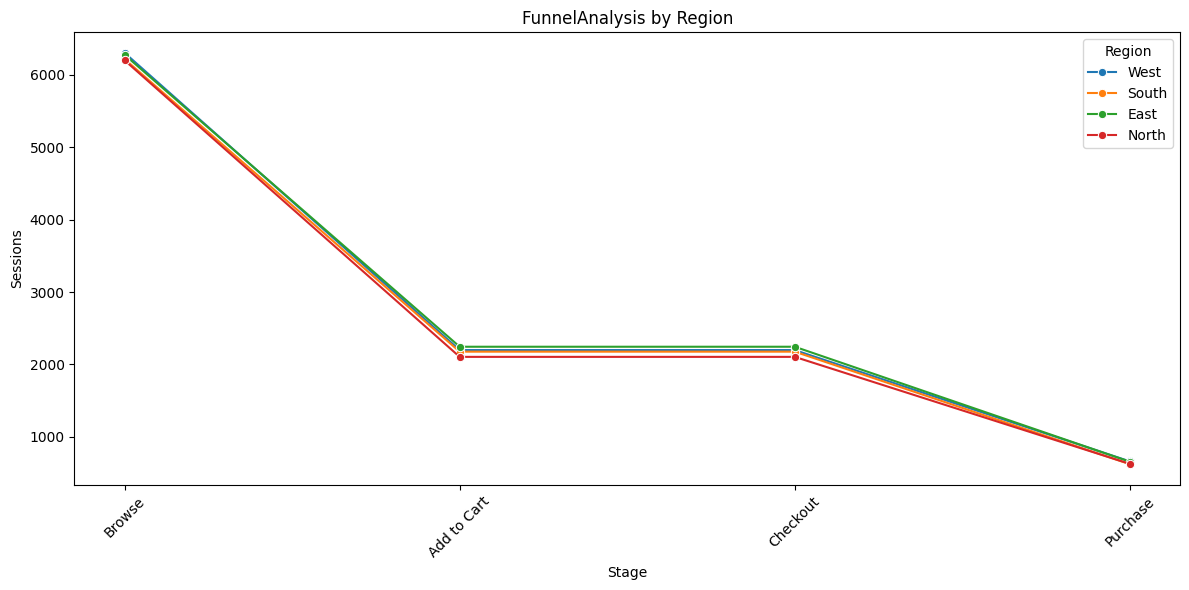

In [33]:
#Regional Analsyis


regional_analysis = session_summary.groupby('Region').agg({

'Session_ID': 'count',

'Revenue': 'sum',

'Session_Duration_Min': 'mean'

}).rename(columns={'Session_ID': 'Total_Sessions', 'Revenue': 'Total_Revenue'})

# Add conversion rates by region

regional_conversion = session_summary [session_summary['Max_Funnel_Stage'] == 'Purchase'].groupby('Region').size()

regional_analysis['Converted_Sessions'] = regional_conversion

regional_analysis ['Conversion_Rate'] = (regional_analysis['Converted_Sessions'] / regional_analysis ['Total_Sessions'] * 100).round(2)

regional_analysis['AOV'] = (regional_analysis ['Total_Revenue'] / regional_analysis['Converted_Sessions']).round(2)

print(" Regional Performance:")

display (regional_analysis)

# Regional funnel visualization

regional_funnel_data = []

for region in df ['Region'].unique():

    region_sessions = session_summary[session_summary['Region'] == region]

    for stage in funnel_stages:

        if stage == 'Browse':

            count = len(region_sessions)

        else:

            count = len(region_sessions [region_sessions['Max_Funnel_Stage'].isin (funnel_stages [funnel_stages.index(stage):])])
        regional_funnel_data.append({'Region': region, 'Stage': stage, 'Sessions': count})
regional_funnel_Df=pd.DataFrame(regional_funnel_data)

plt.figure(figsize=(12,6))
sns.lineplot(data=regional_funnel_Df,x="Stage",y="Sessions",hue="Region",marker="o")
plt.title("FunnelAnalysis by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Device Performance


,Total_Sessions,Revenue,Purchases,Conversion_rate,ADV
Device,,,,,
Desktop,8393,924685.96,812,9.67,1138.78
Phone,8249,938177.68,863,10.46,1087.11
Tablet,8358,950207.11,889,10.64,1068.85


Product Category Performance


,Total_Sessions,Revenue,Purchases,Conversion_Rate,AOV
Product_Category,,,,,
Beauty,5007,554400.24,500,9.99,110.73
Electronics,4935,558284.90,513,10.40,113.13
Fashion,5079,559885.31,509,10.02,110.24
Home,4919,593727.42,527,10.71,120.70
Sports,5060,546772.88,515,10.18,108.06


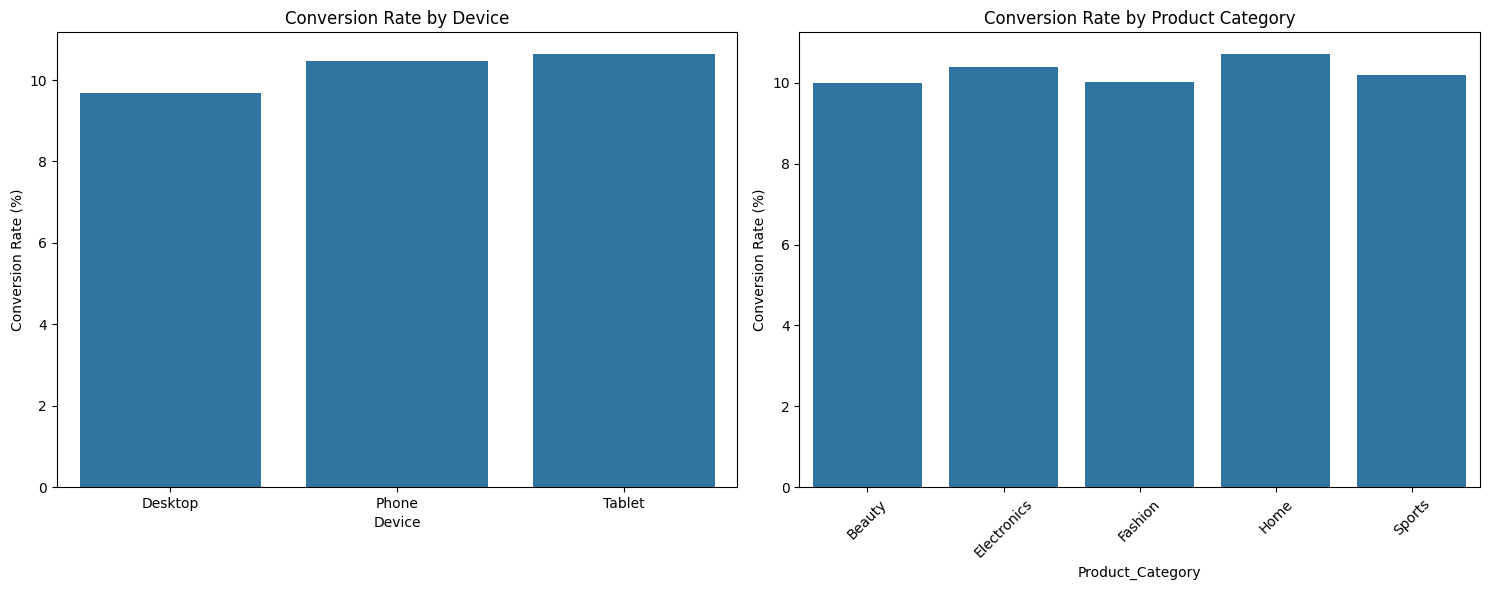

In [34]:

# DEVICE ANALYSIS
# =========================
device_analysis = session_summary.groupby("Device").agg({
    'Session_ID': 'count',
    'Revenue': 'sum',
    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
}).rename(columns={
    'Session_ID': 'Total_Sessions',
    'Max_Funnel_Stage': 'Purchases'
})

device_analysis['Conversion_rate'] = (
    device_analysis['Purchases'] / device_analysis['Total_Sessions'] * 100
).round(2)

device_analysis['ADV'] = (
    device_analysis['Revenue'] / device_analysis['Purchases'].replace(0, 1)
).round(2)

print("Device Performance")
display(device_analysis)


# =========================
# PRODUCT ANALYSIS
# =========================
product_analysis = session_summary.groupby('Product_Category').agg({
    'Session_ID': 'count',
    'Revenue': 'sum',
    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
}).rename(columns={
    'Session_ID': 'Total_Sessions',
    'Max_Funnel_Stage': 'Purchases'
})

product_analysis['Conversion_Rate'] = (
    product_analysis['Purchases'] / product_analysis['Total_Sessions'] * 100
).round(2)

product_analysis['AOV'] = (
    product_analysis['Revenue'] / product_analysis['Total_Sessions']
).round(2)

print("Product Category Performance")
display(product_analysis)


# =========================
# VISUALIZATION
# =========================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Device Conversion Rate
sns.barplot(
    data=device_analysis.reset_index(),
    x='Device',
    y='Conversion_rate',
    ax=ax1
)
ax1.set_title('Conversion Rate by Device')
ax1.set_ylabel('Conversion Rate (%)')

# Product Conversion Rate
sns.barplot(
    data=product_analysis.reset_index(),
    x='Product_Category',
    y='Conversion_Rate',
    ax=ax2
)
ax2.set_title('Conversion Rate by Product Category')
ax2.tick_params(axis="x", rotation=45)
ax2.set_ylabel('Conversion Rate (%)')

plt.tight_layout()
plt.show()

**KPI and Advanced Funnel metrics**


In [35]:
print("Key performance Indicators:")
print("="*50)

#overall KPIs
total_sessions=len(session_summary)
total_revenue = session_summary['Revenue'].sum()
total_orders = len(session_summary[session_summary['Max_Funnel_Stage']=='Purchase'])
overall_conversion_rate=(total_orders/total_sessions*100)

print(f"Overall Conversion Rate:{overall_conversion_rate:.2f}%")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Avg Order Value: ${(total_revenue/total_orders):.2f}")
print(f"Total Sessions:{total_sessions:,}")
print(f"Total Orders:{total_orders:,}")


browse_to_cart = (funnel_df.iloc[1]['Sessions']/funnel_df.iloc[0]['Sessions']*100)
cart_to_checkout = (funnel_df.iloc[2]['Sessions']/funnel_df.iloc[1]['Sessions']*100)
checkout_to_purchase = (funnel_df.iloc[3]['Sessions']/funnel_df.iloc[2]['Sessions']*100)

print(f'\n stage to stage conversion rates:')

print(f"Browse to Add to Cart:{browse_to_cart:.2f}%")
print(f"Add to Cart to Checkout:{cart_to_checkout:.2f}%")
print(f"Checkout to Purchase:{checkout_to_purchase:.2f}%")

revenue_per_browse = total_revenue / funnel_df.iloc[0]['Sessions']
revenue_per_cart = total_revenue / funnel_df.iloc[1]['Sessions']
revenue_per_checkout = total_revenue / funnel_df.iloc[1]['Sessions']

print(f"Revenue per stage by stage:")
print(f"Per Browse Session: ${revenue_per_browse:.2f}%")
print(f"Per Cart Session:{revenue_per_cart:.2f}%")
print(f"per Checkout Session:{revenue_per_checkout:.2f}%")

avg_session_duration = session_summary['Session_Duration_Min'].mean()
print(f"Avg session duration:{avg_session_duration:.2f}minutes")

Key performance Indicators:
Overall Conversion Rate:10.26%
Total Revenue: $2,813,070.75
Avg Order Value: $1097.14
Total Sessions:25,000
Total Orders:2,564

 stage to stage conversion rates:
Browse to Add to Cart:34.89%
Add to Cart to Checkout:100.00%
Checkout to Purchase:29.40%
Revenue per stage by stage:
Per Browse Session: $112.52%
Per Cart Session:322.53%
per Checkout Session:322.53%
Avg session duration:4.01minutes
